TensorFlow Version: 2.20.0

Dataset loaded from: /root/.keras/datasets/fra.txt
Total samples: 5000


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, None, 256) │    323,072 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, None, 256) │    869,120 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, None,     │    525,312 │ embedding_2[0][0] │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, None,     │    525,312 │ embedding_3[0][0… │
│                     │ 256), (None,      │            │ lstm_2[0][1],     │
│                     │ 256), (None,      │            │ lstm_2[0][2]      │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, None, 256) │          0 │ lstm_3[0][0],     │
│ (Attention)         │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, None, 512) │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None,      │  1,741,635 │ concatenate_1[0]… │
│                     │ 3395)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,984,451 (15.20 MB)

 Trainable params: 3,984,451 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.6489 - loss: 3.1586 - val_accuracy: 0.6571 - val_loss: 2.3341
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.7371 - loss: 1.8345 - val_accuracy: 0.6882 - val_loss: 2.2077
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.7461 - loss: 1.6439 - val_accuracy: 0.6906 - val_loss: 2.0814
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7545 - loss: 1.5063 - val_accuracy: 0.6997 - val_loss: 2.0202
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.7649 - loss: 1.3957 - val_accuracy: 0.7112 - val_loss: 1.9753

Generating Attention Heatmap...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step


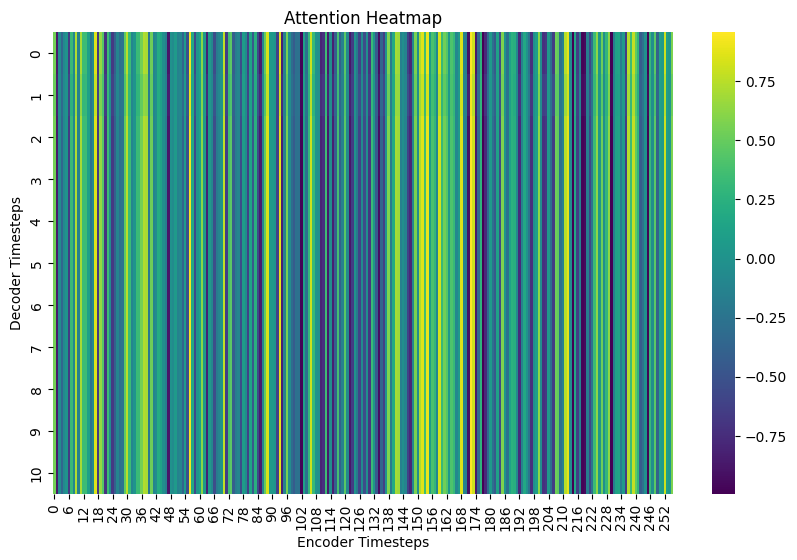


Lab 6 Completed Successfully


In [2]:
# ==========================================
# LAB 6: SEQ2SEQ + ATTENTION HEATMAP
# ==========================================

import tensorflow as tf
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

print("TensorFlow Version:", tf.__version__)

# ==========================================
# STEP 1: DOWNLOAD + FIX DATASET
# ==========================================

print("\nDownloading dataset...")

zip_path = tf.keras.utils.get_file(
    fname="fra-eng.zip",
    origin="http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip"
)

# Force extract
extract_dir = os.path.dirname(zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Find fra.txt automatically
data_path = None
for root, dirs, files in os.walk(extract_dir):
    if "fra.txt" in files:
        data_path = os.path.join(root, "fra.txt")
        break

if data_path is None:
    raise FileNotFoundError("fra.txt not found!")

print("Dataset loaded from:", data_path)

# ==========================================
# STEP 2: LOAD DATA
# ==========================================

lines = open(data_path, encoding="utf-8").read().split("\n")

input_texts = []
target_texts = []

for line in lines[:5000]:   # reduce if slow
    if "\t" not in line:
        continue

    parts = line.split("\t")

    if len(parts) < 2:
        continue

    eng = parts[0]
    fra = parts[1]

    input_texts.append(eng)
    target_texts.append("\t " + fra + " \n")

print("Total samples:", len(input_texts))

# ==========================================
# STEP 3: TOKENIZATION
# ==========================================

input_tokenizer = Tokenizer()
input_tokenizer.fit_on_texts(input_texts)

input_seq = input_tokenizer.texts_to_sequences(input_texts)
max_len_enc = max(len(s) for s in input_seq)
input_seq = pad_sequences(input_seq, maxlen=max_len_enc, padding="post")

target_tokenizer = Tokenizer(filters="")
target_tokenizer.fit_on_texts(target_texts)

target_seq = target_tokenizer.texts_to_sequences(target_texts)
max_len_dec = max(len(s) for s in target_seq)
target_seq = pad_sequences(target_seq, maxlen=max_len_dec, padding="post")

num_enc = len(input_tokenizer.word_index) + 1
num_dec = len(target_tokenizer.word_index) + 1

# Prepare decoder data
decoder_input = target_seq[:, :-1]
decoder_target = target_seq[:, 1:]

decoder_target = tf.keras.utils.to_categorical(
    decoder_target, num_classes=num_dec
)

# ==========================================
# STEP 4: BUILD MODEL WITH ATTENTION
# ==========================================

latent_dim = 256

# Encoder
encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(num_enc, latent_dim)(encoder_inputs)

encoder_outputs, state_h, state_c = LSTM(
    latent_dim, return_sequences=True, return_state=True
)(enc_emb)

# Decoder
decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(num_dec, latent_dim)(decoder_inputs)

decoder_outputs, _, _ = LSTM(
    latent_dim, return_sequences=True, return_state=True
)(dec_emb, initial_state=[state_h, state_c])

# Attention
attention_layer = Attention(name="attention_layer")
attention_output = attention_layer([decoder_outputs, encoder_outputs])

# Combine
concat = Concatenate(axis=-1)([decoder_outputs, attention_output])

# Output
decoder_dense = Dense(num_dec, activation="softmax")
outputs = decoder_dense(concat)

# Model
model = Model([encoder_inputs, decoder_inputs], outputs)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==========================================
# STEP 5: TRAIN
# ==========================================

model.fit(
    [input_seq, decoder_input],
    decoder_target,
    batch_size=64,
    epochs=5,
    validation_split=0.2
)

# ==========================================
# STEP 6: ATTENTION HEATMAP
# ==========================================

print("\nGenerating Attention Heatmap...")

# Extract attention output
attention_model = Model(
    inputs=model.input,
    outputs=model.get_layer("attention_layer").output
)

sample_input = input_seq[0:1]
sample_decoder = decoder_input[0:1]

attention_weights = attention_model.predict([sample_input, sample_decoder])

attention_matrix = attention_weights[0]

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(attention_matrix, cmap="viridis")

plt.title("Attention Heatmap")
plt.xlabel("Encoder Timesteps")
plt.ylabel("Decoder Timesteps")

plt.show()

print("\nLab 6 Completed Successfully")